# Consistent ROM parameter sweep

## Purpose

This notebook demonstrates the final physically consistent reduced-order model
without fitting or selecting any new models.

The packaged ROM predicts the bulk and small-species volume-fraction fields
directly. The large-species field is then calculated as

$$
\widehat{\phi}_{\mathrm{large}}
=
\widehat{\phi}_{\mathrm{bulk}}
-
\widehat{\phi}_{\mathrm{small}}.
$$

The objectives are to:

1. reload and validate the packaged ROM;
2. predict fields over a dense particle-size-ratio sweep;
3. verify physical consistency across the complete sweep;
4. measure prediction time and package efficiency;
5. examine how the predicted fields and segregation measures vary continuously
   with particle-size ratio.

No POD basis, neural surrogate or hyperparameter is refitted in this notebook.

In [1]:
from pathlib import Path
from time import perf_counter
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(
    starting_path: Path,
) -> Path:
    """Locate the repository root."""
    starting_path = starting_path.resolve()

    for candidate in (
        starting_path,
        *starting_path.parents,
    ):
        if (
            (candidate / "data").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "results").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

PACKAGE_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cg_phi_consistent_bulk_small_rom.joblib"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

TABLE_DIR = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if not PACKAGE_PATH.exists():
    raise FileNotFoundError(
        "The packaged ROM was not found:\n"
        f"{PACKAGE_PATH}"
    )


consistent_rom_package = joblib.load(
    PACKAGE_PATH
)

print("Python executable:")
print(sys.executable)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nLoaded package:")
print(PACKAGE_PATH)

print(
    "\nPackage size:",
    f"{PACKAGE_PATH.stat().st_size / 1024**2:.3f} MB",
)

print(
    "Schema version:",
    consistent_rom_package[
        "schema_version"
    ],
)

print(
    "Deployment strategy:",
    consistent_rom_package[
        "deployment_strategy"
    ],
)

print(
    "Direct model fields:",
    consistent_rom_package[
        "direct_model_fields"
    ],
)

print(
    "Derived field:",
    consistent_rom_package[
        "derived_field"
    ],
)

print(
    "Physical identity:",
    consistent_rom_package[
        "physical_identity"
    ],
)


x_grid = consistent_rom_package[
    "x_grid"
]

z_grid = consistent_rom_package[
    "z_grid"
]

output_time = consistent_rom_package[
    "output_time"
]

training_parameter_minimum = float(
    consistent_rom_package[
        "training_parameter_minimum"
    ]
)

training_parameter_maximum = float(
    consistent_rom_package[
        "training_parameter_maximum"
    ]
)


print("\nSpatial and parameter information")
print("---------------------------------")

print(
    "Grid:",
    f"{x_grid.size} by {z_grid.size}",
)

print(
    "Grid points per field:",
    x_grid.size * z_grid.size,
)

print(
    "Output time:",
    output_time,
)

print(
    "Training parameter interval:",
    f"{training_parameter_minimum:.6f}",
    "to",
    f"{training_parameter_maximum:.6f}",
)


for field_name in (
    "bulk",
    "small",
):
    model = consistent_rom_package[
        "models"
    ][
        field_name
    ]

    print(
        f"\n{field_name.capitalize()} model:"
    )

    print(
        "  POD rank:",
        model["rank"],
    )

    print(
        "  Mean-field shape:",
        model[
            "mean_snapshot"
        ].shape,
    )

    print(
        "  POD-basis shape:",
        model[
            "basis"
        ].shape,
    )

    assert model[
        "mean_snapshot"
    ].shape == (
        10000,
        1,
    )

    assert model[
        "basis"
    ].shape == (
        10000,
        model["rank"],
    )

    assert np.isfinite(
        model["mean_snapshot"]
    ).all()

    assert np.isfinite(
        model["basis"]
    ).all()


assert (
    consistent_rom_package[
        "deployment_strategy"
    ]
    == "bulk_small_derive_large"
)

assert tuple(
    consistent_rom_package[
        "direct_model_fields"
    ]
) == (
    "bulk",
    "small",
)

assert (
    consistent_rom_package[
        "derived_field"
    ]
    == "large"
)

assert x_grid.shape == (100,)
assert z_grid.shape == (100,)

print(
    "\nPackaged-ROM validation checks passed."
)

Python executable:
/Users/rallen/Documents/msc-rom-particle-systems/.venv/bin/python

Project root:
/Users/rallen/Documents/msc-rom-particle-systems

Loaded package:
/Users/rallen/Documents/msc-rom-particle-systems/data/processed/cg_phi_consistent_bulk_small_rom.joblib

Package size: 0.445 MB
Schema version: 1
Deployment strategy: bulk_small_derive_large
Direct model fields: ('bulk', 'small')
Derived field: large
Physical identity: bulk = small + large

Spatial and parameter information
---------------------------------
Grid: 100 by 100
Grid points per field: 10000
Output time: [1720.72]
Training parameter interval: 1.000000 to 2.000000

Bulk model:
  POD rank: 6
  Mean-field shape: (10000, 1)
  POD-basis shape: (10000, 6)

Small model:
  POD rank: 3
  Mean-field shape: (10000, 1)
  POD-basis shape: (10000, 3)

Packaged-ROM validation checks passed.


In [2]:
def predict_direct_field(
    model: dict,
    query_parameters: np.ndarray,
) -> np.ndarray:
    """
    Predict a complete field using one packaged POD-neural ROM.
    """
    query_parameters = np.asarray(
        query_parameters,
        dtype=float,
    ).reshape(-1)

    scaled_inputs = model[
        "input_scaler"
    ].transform(
        query_parameters.reshape(
            -1,
            1,
        )
    )

    scaled_coefficients = np.asarray(
        model[
            "neural_model"
        ].predict(
            scaled_inputs
        )
    )

    if scaled_coefficients.ndim == 1:
        scaled_coefficients = (
            scaled_coefficients.reshape(
                -1,
                1,
            )
        )

    predicted_coefficients = model[
        "output_scaler"
    ].inverse_transform(
        scaled_coefficients
    ).T

    predicted_snapshots = (
        model["mean_snapshot"]
        + model["basis"]
        @ predicted_coefficients
    )

    return predicted_snapshots


def predict_consistent_fields(
    package: dict,
    query_parameters: np.ndarray,
) -> dict:
    """
    Predict bulk and small fields and derive the large field exactly.
    """
    query_parameters = np.asarray(
        query_parameters,
        dtype=float,
    ).reshape(-1)

    parameter_minimum = float(
        package[
            "training_parameter_minimum"
        ]
    )

    parameter_maximum = float(
        package[
            "training_parameter_maximum"
        ]
    )

    if np.any(
        query_parameters
        < parameter_minimum - 1e-12
    ) or np.any(
        query_parameters
        > parameter_maximum + 1e-12
    ):
        raise ValueError(
            "A requested parameter lies outside "
            "the fitted interval."
        )

    bulk_predictions = predict_direct_field(
        package[
            "models"
        ][
            "bulk"
        ],
        query_parameters,
    )

    small_predictions = predict_direct_field(
        package[
            "models"
        ][
            "small"
        ],
        query_parameters,
    )

    large_predictions = (
        bulk_predictions
        - small_predictions
    )

    return {
        "bulk": bulk_predictions,
        "small": small_predictions,
        "large": large_predictions,
    }


number_of_sweep_parameters = 201

dense_parameters = np.linspace(
    training_parameter_minimum,
    training_parameter_maximum,
    number_of_sweep_parameters,
)

dense_predictions = predict_consistent_fields(
    consistent_rom_package,
    dense_parameters,
)


print("Dense parameter sweep")
print("---------------------")

print(
    "Number of parameter values:",
    dense_parameters.size,
)

print(
    "Parameter range:",
    f"{dense_parameters.min():.6f}",
    "to",
    f"{dense_parameters.max():.6f}",
)

print(
    "Parameter spacing:",
    f"{np.diff(dense_parameters).mean():.6f}",
)


for field_name, predictions in (
    dense_predictions.items()
):
    print(
        f"{field_name.capitalize()} prediction shape:",
        predictions.shape,
    )

    print(
        f"{field_name.capitalize()} range:",
        f"{predictions.min():.6e}",
        "to",
        f"{predictions.max():.6e}",
    )

    assert predictions.shape == (
        10000,
        number_of_sweep_parameters,
    )

    assert np.isfinite(
        predictions
    ).all()


dense_identity_residual = (
    dense_predictions["bulk"]
    - dense_predictions["small"]
    - dense_predictions["large"]
)

maximum_dense_identity_error = float(
    np.max(
        np.abs(
            dense_identity_residual
        )
    )
)

print(
    "\nMaximum pointwise identity error:",
    f"{maximum_dense_identity_error:.6e}",
)

assert maximum_dense_identity_error < 1e-12

print(
    "\nDense parameter-sweep checks passed."
)

Dense parameter sweep
---------------------
Number of parameter values: 201
Parameter range: 1.000000 to 2.000000
Parameter spacing: 0.005000
Bulk prediction shape: (10000, 201)
Bulk range: -5.235729e-06 to 5.755945e-01
Small prediction shape: (10000, 201)
Small range: -2.159611e-06 to 5.380947e-01
Large prediction shape: (10000, 201)
Large range: -2.511222e-03 to 4.841051e-01

Maximum pointwise identity error: 0.000000e+00

Dense parameter-sweep checks passed.


In [3]:
x_spacing = float(
    np.mean(
        np.diff(x_grid)
    )
)

z_spacing = float(
    np.mean(
        np.diff(z_grid)
    )
)

cell_area = (
    x_spacing
    * z_spacing
)


sweep_diagnostic_records = []

for parameter_index, size_ratio in enumerate(
    dense_parameters
):
    bulk_snapshot = dense_predictions[
        "bulk"
    ][
        :,
        parameter_index,
    ]

    small_snapshot = dense_predictions[
        "small"
    ][
        :,
        parameter_index,
    ]

    large_snapshot = dense_predictions[
        "large"
    ][
        :,
        parameter_index,
    ]

    pointwise_identity_error = float(
        np.max(
            np.abs(
                bulk_snapshot
                - small_snapshot
                - large_snapshot
            )
        )
    )

    sweep_diagnostic_records.append(
        {
            "size_ratio": float(
                size_ratio
            ),
            "bulk_integrated_volume": float(
                bulk_snapshot.sum()
                * cell_area
            ),
            "small_integrated_volume": float(
                small_snapshot.sum()
                * cell_area
            ),
            "large_integrated_volume": float(
                large_snapshot.sum()
                * cell_area
            ),
            "bulk_minimum": float(
                bulk_snapshot.min()
            ),
            "small_minimum": float(
                small_snapshot.min()
            ),
            "large_minimum": float(
                large_snapshot.min()
            ),
            "bulk_maximum": float(
                bulk_snapshot.max()
            ),
            "small_maximum": float(
                small_snapshot.max()
            ),
            "large_maximum": float(
                large_snapshot.max()
            ),
            "bulk_fraction_below_minus_1e_5": float(
                np.mean(
                    bulk_snapshot < -1e-5
                )
            ),
            "small_fraction_below_minus_1e_5": float(
                np.mean(
                    small_snapshot < -1e-5
                )
            ),
            "large_fraction_below_minus_1e_5": float(
                np.mean(
                    large_snapshot < -1e-5
                )
            ),
            "pointwise_identity_error": (
                pointwise_identity_error
            ),
        }
    )


dense_sweep_diagnostics = pd.DataFrame(
    sweep_diagnostic_records
)


# Warm up the loaded estimators before timing.
for _ in range(5):
    predict_consistent_fields(
        consistent_rom_package,
        np.array(
            [
                1.5,
            ]
        ),
    )


single_parameter_repetitions = 500
single_parameter_times_ms = []

for _ in range(
    single_parameter_repetitions
):
    start_time = perf_counter()

    predict_consistent_fields(
        consistent_rom_package,
        np.array(
            [
                1.5,
            ]
        ),
    )

    elapsed_ms = (
        perf_counter()
        - start_time
    ) * 1000.0

    single_parameter_times_ms.append(
        elapsed_ms
    )


dense_sweep_repetitions = 10
dense_sweep_times_ms = []

for _ in range(
    dense_sweep_repetitions
):
    start_time = perf_counter()

    predict_consistent_fields(
        consistent_rom_package,
        dense_parameters,
    )

    elapsed_ms = (
        perf_counter()
        - start_time
    ) * 1000.0

    dense_sweep_times_ms.append(
        elapsed_ms
    )


single_parameter_times_ms = np.asarray(
    single_parameter_times_ms
)

dense_sweep_times_ms = np.asarray(
    dense_sweep_times_ms
)


timing_summary = pd.DataFrame(
    [
        {
            "benchmark": (
                "single_parameter_three_fields"
            ),
            "number_of_parameters": 1,
            "number_of_repetitions": (
                single_parameter_repetitions
            ),
            "median_time_ms": float(
                np.median(
                    single_parameter_times_ms
                )
            ),
            "mean_time_ms": float(
                single_parameter_times_ms.mean()
            ),
            "percentile_95_time_ms": float(
                np.percentile(
                    single_parameter_times_ms,
                    95,
                )
            ),
        },
        {
            "benchmark": (
                "dense_201_parameter_sweep"
            ),
            "number_of_parameters": int(
                dense_parameters.size
            ),
            "number_of_repetitions": (
                dense_sweep_repetitions
            ),
            "median_time_ms": float(
                np.median(
                    dense_sweep_times_ms
                )
            ),
            "mean_time_ms": float(
                dense_sweep_times_ms.mean()
            ),
            "percentile_95_time_ms": float(
                np.percentile(
                    dense_sweep_times_ms,
                    95,
                )
            ),
        },
    ]
)

timing_summary[
    "median_time_per_parameter_ms"
] = (
    timing_summary[
        "median_time_ms"
    ]
    / timing_summary[
        "number_of_parameters"
    ]
)


print("Dense-sweep physical diagnostics")
print("--------------------------------")

print(
    "Maximum identity error:",
    f"{dense_sweep_diagnostics[
        'pointwise_identity_error'
    ].max():.6e}",
)

print(
    "Bulk integrated-volume range:",
    f"{dense_sweep_diagnostics[
        'bulk_integrated_volume'
    ].min():.6f}",
    "to",
    f"{dense_sweep_diagnostics[
        'bulk_integrated_volume'
    ].max():.6f}",
)

print(
    "Small integrated-volume range:",
    f"{dense_sweep_diagnostics[
        'small_integrated_volume'
    ].min():.6f}",
    "to",
    f"{dense_sweep_diagnostics[
        'small_integrated_volume'
    ].max():.6f}",
)

print(
    "Large integrated-volume range:",
    f"{dense_sweep_diagnostics[
        'large_integrated_volume'
    ].min():.6f}",
    "to",
    f"{dense_sweep_diagnostics[
        'large_integrated_volume'
    ].max():.6f}",
)

print(
    "Minimum predicted large value:",
    f"{dense_sweep_diagnostics[
        'large_minimum'
    ].min():.6e}",
)


print("\nInference timing")
print("----------------")

display(
    timing_summary
)


sweep_diagnostics_path = (
    TABLE_DIR
    / "cg_phi_consistent_rom_dense_sweep_diagnostics.csv"
)

timing_summary_path = (
    TABLE_DIR
    / "cg_phi_consistent_rom_inference_timing.csv"
)

dense_sweep_diagnostics.to_csv(
    sweep_diagnostics_path,
    index=False,
)

timing_summary.to_csv(
    timing_summary_path,
    index=False,
)


assert (
    dense_sweep_diagnostics[
        "pointwise_identity_error"
    ].max()
    < 1e-12
)

print("\nSaved dense-sweep diagnostics:")
print(sweep_diagnostics_path)

print("\nSaved inference timing:")
print(timing_summary_path)

display(
    dense_sweep_diagnostics.head(10)
)

Dense-sweep physical diagnostics
--------------------------------
Maximum identity error: 0.000000e+00
Bulk integrated-volume range: 565.530806 to 565.554820
Small integrated-volume range: 282.753004 to 282.778095
Large integrated-volume range: 282.766021 to 282.800511
Minimum predicted large value: -2.511222e-03

Inference timing
----------------


,benchmark,number_of_parameters,number_of_repetitions,median_time_ms,mean_time_ms,percentile_95_time_ms,median_time_per_parameter_ms
0,single_parameter_three_fields,1,500,0.854386,0.976727,1.581060,0.854386
1,dense_201_parameter_sweep,201,10,25.310297,27.056501,35.343794,0.125922



Saved dense-sweep diagnostics:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_consistent_rom_dense_sweep_diagnostics.csv

Saved inference timing:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_consistent_rom_inference_timing.csv


,size_ratio,bulk_integrated_volume,small_integrated_volume,large_integrated_volume,bulk_minimum,small_minimum,large_minimum,bulk_maximum,small_maximum,large_maximum,bulk_fraction_below_minus_1e_5,small_fraction_below_minus_1e_5,large_fraction_below_minus_1e_5,pointwise_identity_error
0,1.000,565.554814,282.778095,282.776719,-0.000005,-2.159611e-06,-0.000011,0.557515,0.293377,0.291992,0.0,0.0,0.0002,0.0
1,1.005,565.553722,282.777704,282.776018,-0.000005,-1.999976e-06,-0.000011,0.557537,0.296364,0.293547,0.0,0.0,0.0001,0.0
2,1.010,565.552620,282.777300,282.775320,-0.000005,-1.836109e-06,-0.000010,0.557560,0.299759,0.295146,0.0,0.0,0.0001,0.0
3,1.015,565.551513,282.776885,282.774627,-0.000005,-1.668086e-06,-0.000009,0.557583,0.303463,0.296790,0.0,0.0,0.0000,0.0
4,1.020,565.550403,282.776459,282.773943,-0.000004,-1.496005e-06,-0.000009,0.557606,0.307362,0.298476,0.0,0.0,0.0000,0.0
5,1.025,565.549294,282.776023,282.773271,-0.000004,-1.319983e-06,-0.000008,0.557629,0.311391,0.300203,0.0,0.0,0.0000,0.0
6,1.030,565.548190,282.775577,282.772613,-0.000004,-1.140160e-06,-0.000008,0.557653,0.315511,0.301969,0.0,0.0,0.0000,0.0
7,1.035,565.547095,282.775122,282.771973,-0.000004,-9.566923e-07,-0.000007,0.557678,0.319807,0.303772,0.0,0.0,0.0000,0.0
8,1.040,565.546013,282.774659,282.771354,-0.000004,-7.697575e-07,-0.000007,0.557704,0.324220,0.305608,0.0,0.0,0.0000,0.0
9,1.045,565.544948,282.774189,282.770758,-0.000003,-5.795483e-07,-0.000006,0.557730,0.328717,0.307476,0.0,0.0,0.0000,0.0


In [4]:
def calculate_species_metrics(
    size_ratios: np.ndarray,
    small_snapshots: np.ndarray,
    large_snapshots: np.ndarray,
) -> pd.DataFrame:
    """
    Calculate segregation diagnostics for paired species fields.

    No clipping is applied to the ROM predictions.
    """
    size_ratios = np.asarray(
        size_ratios,
        dtype=float,
    ).reshape(-1)

    if small_snapshots.shape != large_snapshots.shape:
        raise ValueError(
            "Small- and large-species matrices "
            "must have identical shapes."
        )

    if small_snapshots.shape[1] != size_ratios.size:
        raise ValueError(
            "The number of snapshots does not match "
            "the number of parameters."
        )

    x_coordinates = np.repeat(
        x_grid,
        z_grid.size,
    )

    z_coordinates = np.tile(
        z_grid,
        x_grid.size,
    )

    metric_records = []

    for parameter_index, size_ratio in enumerate(
        size_ratios
    ):
        small_snapshot = small_snapshots[
            :,
            parameter_index,
        ]

        large_snapshot = large_snapshots[
            :,
            parameter_index,
        ]

        combined_species_sum = float(
            np.sum(
                small_snapshot
                + large_snapshot
            )
        )

        if combined_species_sum <= 0.0:
            raise ValueError(
                "The combined species field has "
                "non-positive integrated volume."
            )

        normalised_l1_separation = float(
            np.sum(
                np.abs(
                    small_snapshot
                    - large_snapshot
                )
            )
            / combined_species_sum
        )

        overlap_fraction = float(
            2.0
            * np.sum(
                np.minimum(
                    small_snapshot,
                    large_snapshot,
                )
            )
            / combined_species_sum
        )

        active_points = (
            (np.abs(small_snapshot) > 1e-12)
            | (np.abs(large_snapshot) > 1e-12)
        )

        active_small = small_snapshot[
            active_points
        ]

        active_large = large_snapshot[
            active_points
        ]

        if (
            active_small.size > 1
            and np.std(active_small) > 0.0
            and np.std(active_large) > 0.0
        ):
            spatial_correlation = float(
                np.corrcoef(
                    active_small,
                    active_large,
                )[0, 1]
            )
        else:
            spatial_correlation = np.nan

        small_total = float(
            small_snapshot.sum()
        )

        large_total = float(
            large_snapshot.sum()
        )

        if (
            small_total <= 0.0
            or large_total <= 0.0
        ):
            raise ValueError(
                "A species field has non-positive "
                "integrated volume."
            )

        small_centre_x = float(
            np.sum(
                x_coordinates
                * small_snapshot
            )
            / small_total
        )

        small_centre_z = float(
            np.sum(
                z_coordinates
                * small_snapshot
            )
            / small_total
        )

        large_centre_x = float(
            np.sum(
                x_coordinates
                * large_snapshot
            )
            / large_total
        )

        large_centre_z = float(
            np.sum(
                z_coordinates
                * large_snapshot
            )
            / large_total
        )

        centre_of_mass_separation = float(
            np.sqrt(
                (
                    large_centre_x
                    - small_centre_x
                )**2
                + (
                    large_centre_z
                    - small_centre_z
                )**2
            )
        )

        metric_records.append(
            {
                "size_ratio": float(
                    size_ratio
                ),
                "normalised_l1_separation": (
                    normalised_l1_separation
                ),
                "overlap_fraction": (
                    overlap_fraction
                ),
                "small_large_spatial_correlation": (
                    spatial_correlation
                ),
                "small_centre_x": (
                    small_centre_x
                ),
                "small_centre_z": (
                    small_centre_z
                ),
                "large_centre_x": (
                    large_centre_x
                ),
                "large_centre_z": (
                    large_centre_z
                ),
                "centre_of_mass_separation": (
                    centre_of_mass_separation
                ),
            }
        )

    return pd.DataFrame(
        metric_records
    )


dense_rom_segregation_metrics = (
    calculate_species_metrics(
        size_ratios=dense_parameters,
        small_snapshots=dense_predictions[
            "small"
        ],
        large_snapshots=dense_predictions[
            "large"
        ],
    )
)


print("Dense ROM segregation metrics")
print("-----------------------------")

print(
    "L1-separation range:",
    f"{dense_rom_segregation_metrics[
        'normalised_l1_separation'
    ].min():.6f}",
    "to",
    f"{dense_rom_segregation_metrics[
        'normalised_l1_separation'
    ].max():.6f}",
)

print(
    "Overlap-fraction range:",
    f"{dense_rom_segregation_metrics[
        'overlap_fraction'
    ].min():.6f}",
    "to",
    f"{dense_rom_segregation_metrics[
        'overlap_fraction'
    ].max():.6f}",
)

print(
    "Correlation range:",
    f"{dense_rom_segregation_metrics[
        'small_large_spatial_correlation'
    ].min():.6f}",
    "to",
    f"{dense_rom_segregation_metrics[
        'small_large_spatial_correlation'
    ].max():.6f}",
)

print(
    "Centre-separation range:",
    f"{dense_rom_segregation_metrics[
        'centre_of_mass_separation'
    ].min():.6f}",
    "to",
    f"{dense_rom_segregation_metrics[
        'centre_of_mass_separation'
    ].max():.6f}",
)


dense_segregation_path = (
    TABLE_DIR
    / "cg_phi_consistent_rom_dense_segregation_metrics.csv"
)

dense_rom_segregation_metrics.to_csv(
    dense_segregation_path,
    index=False,
)

print("\nSaved dense segregation metrics:")
print(dense_segregation_path)

display(
    dense_rom_segregation_metrics.head(10)
)

Dense ROM segregation metrics
-----------------------------
L1-separation range: 0.045328 to 0.570288
Overlap-fraction range: 0.429712 to 0.954672
Correlation range: 0.096760 to 0.988638
Centre-separation range: 0.192249 to 1.654428

Saved dense segregation metrics:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_consistent_rom_dense_segregation_metrics.csv


,size_ratio,normalised_l1_separation,overlap_fraction,small_large_spatial_correlation,small_centre_x,small_centre_z,large_centre_x,large_centre_z,centre_of_mass_separation
0,1.000,0.045328,0.954672,0.988638,-12.215515,-10.047915,-12.257528,-10.235518,0.192249
1,1.005,0.049866,0.950134,0.986071,-12.214238,-10.038598,-12.266365,-10.235802,0.203977
2,1.010,0.054557,0.945443,0.983142,-12.212924,-10.028988,-12.275320,-10.236280,0.216478
3,1.015,0.059390,0.940610,0.979832,-12.211572,-10.019096,-12.284371,-10.236972,0.229716
4,1.020,0.064356,0.935644,0.976124,-12.210183,-10.008935,-12.293493,-10.237899,0.243649
5,1.025,0.069445,0.930555,0.971996,-12.208759,-9.998519,-12.302662,-10.239080,0.258239
6,1.030,0.074652,0.925348,0.967433,-12.207301,-9.987866,-12.311852,-10.240535,0.273446
7,1.035,0.079969,0.920031,0.962446,-12.205809,-9.976996,-12.321036,-10.242281,0.289229
8,1.040,0.085387,0.914613,0.957008,-12.204285,-9.965929,-12.330188,-10.244332,0.305548
9,1.045,0.090895,0.909105,0.951091,-12.202732,-9.954690,-12.339280,-10.246703,0.322362


In [5]:
exact_segregation_path = (
    TABLE_DIR
    / "cg_phi_species_segregation_diagnostics.csv"
)

if not exact_segregation_path.exists():
    raise FileNotFoundError(
        "The exact segregation diagnostics "
        "from Notebook 6 were not found:\n"
        f"{exact_segregation_path}"
    )


exact_segregation_metrics = pd.read_csv(
    exact_segregation_path
).sort_values(
    "size_ratio"
).reset_index(
    drop=True
)


reserved_test_indices = np.asarray(
    consistent_rom_package[
        "reserved_test_indices"
    ],
    dtype=int,
)

reserved_metric_parameters = (
    exact_segregation_metrics[
        "size_ratio"
    ].to_numpy()[
        reserved_test_indices
    ]
)

reserved_metric_predictions = (
    predict_consistent_fields(
        consistent_rom_package,
        reserved_metric_parameters,
    )
)

reserved_rom_segregation_metrics = (
    calculate_species_metrics(
        size_ratios=reserved_metric_parameters,
        small_snapshots=(
            reserved_metric_predictions[
                "small"
            ]
        ),
        large_snapshots=(
            reserved_metric_predictions[
                "large"
            ]
        ),
    )
)

reserved_exact_segregation_metrics = (
    exact_segregation_metrics.iloc[
        reserved_test_indices
    ]
    .reset_index(
        drop=True
    )
)


segregation_metric_names = [
    "normalised_l1_separation",
    "overlap_fraction",
    "small_large_spatial_correlation",
    "centre_of_mass_separation",
]

reserved_metric_comparison = pd.DataFrame(
    {
        "size_ratio": (
            reserved_metric_parameters
        )
    }
)

reserved_metric_summary_records = []

for metric_name in segregation_metric_names:
    exact_values = (
        reserved_exact_segregation_metrics[
            metric_name
        ].to_numpy()
    )

    predicted_values = (
        reserved_rom_segregation_metrics[
            metric_name
        ].to_numpy()
    )

    absolute_errors = np.abs(
        predicted_values
        - exact_values
    )

    reserved_metric_comparison[
        f"exact_{metric_name}"
    ] = exact_values

    reserved_metric_comparison[
        f"rom_{metric_name}"
    ] = predicted_values

    reserved_metric_comparison[
        f"absolute_error_{metric_name}"
    ] = absolute_errors

    reserved_metric_summary_records.append(
        {
            "metric": metric_name,
            "mean_exact_value": float(
                exact_values.mean()
            ),
            "mean_rom_value": float(
                predicted_values.mean()
            ),
            "mean_absolute_error": float(
                absolute_errors.mean()
            ),
            "maximum_absolute_error": float(
                absolute_errors.max()
            ),
            "root_mean_squared_error": float(
                np.sqrt(
                    np.mean(
                        (
                            predicted_values
                            - exact_values
                        )**2
                    )
                )
            ),
        }
    )


reserved_metric_summary = pd.DataFrame(
    reserved_metric_summary_records
)


print("Reserved-case segregation validation")
print("------------------------------------")

display(
    reserved_metric_summary
)


reserved_metric_comparison_path = (
    TABLE_DIR
    / "cg_phi_consistent_rom_reserved_segregation_detailed.csv"
)

reserved_metric_summary_path = (
    TABLE_DIR
    / "cg_phi_consistent_rom_reserved_segregation_summary.csv"
)

reserved_metric_comparison.to_csv(
    reserved_metric_comparison_path,
    index=False,
)

reserved_metric_summary.to_csv(
    reserved_metric_summary_path,
    index=False,
)

print("Saved detailed reserved comparison:")
print(reserved_metric_comparison_path)

print("\nSaved reserved summary:")
print(reserved_metric_summary_path)

display(
    reserved_metric_comparison
)

Reserved-case segregation validation
------------------------------------


,metric,mean_exact_value,mean_rom_value,mean_absolute_error,maximum_absolute_error,root_mean_squared_error
0,normalised_l1_separation,0.414401,0.413300,0.003289,0.007788,0.003993
1,overlap_fraction,0.585635,0.586700,0.003282,0.007770,0.003996
2,small_large_spatial_correlation,0.276770,0.364463,0.087693,0.125173,0.092874
3,centre_of_mass_separation,1.255840,1.253606,0.011572,0.020022,0.013443


Saved detailed reserved comparison:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_consistent_rom_reserved_segregation_detailed.csv

Saved reserved summary:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_consistent_rom_reserved_segregation_summary.csv


,size_ratio,exact_normalised_l1_separation,rom_normalised_l1_separation,absolute_error_normalised_l1_separation,exact_overlap_fraction,rom_overlap_fraction,absolute_error_overlap_fraction,exact_small_large_spatial_correlation,rom_small_large_spatial_correlation,absolute_error_small_large_spatial_correlation,exact_centre_of_mass_separation,rom_centre_of_mass_separation,absolute_error_centre_of_mass_separation
0,1.050505,0.099727,0.097056,0.002671,0.900296,0.902944,0.002648,0.928869,0.944056,0.015187,0.331450,0.341397,0.009948
1,1.151515,0.214220,0.211845,0.002375,0.785781,0.788155,0.002374,0.680149,0.752766,0.072616,0.737628,0.723037,0.014590
2,1.252525,0.308742,0.307622,0.001120,0.691301,0.692378,0.001077,0.470283,0.554575,0.084293,1.014062,1.030097,0.016034
3,1.353535,0.393940,0.390269,0.003671,0.606089,0.609731,0.003642,0.264516,0.389688,0.125173,1.248564,1.248363,0.000202
4,1.454545,0.450601,0.450869,0.000267,0.549427,0.549131,0.000296,0.192863,0.278895,0.086031,1.410180,1.392086,0.018094
5,1.555556,0.492764,0.492103,0.000660,0.507314,0.507897,0.000582,0.087653,0.208612,0.120959,1.473792,1.475763,0.001971
6,1.656566,0.515283,0.521050,0.005767,0.484752,0.478950,0.005802,0.098707,0.162606,0.063899,1.527199,1.530630,0.003431
7,1.757576,0.548822,0.541034,0.007788,0.451196,0.458966,0.007770,0.024425,0.134770,0.110345,1.587113,1.567091,0.020022
8,1.858586,0.550109,0.555015,0.004906,0.449971,0.444985,0.004987,0.016853,0.116461,0.099608,1.609707,1.593582,0.016126
9,1.959596,0.569807,0.566138,0.003669,0.430219,0.433862,0.003643,0.003376,0.102201,0.098824,1.618705,1.634011,0.015306


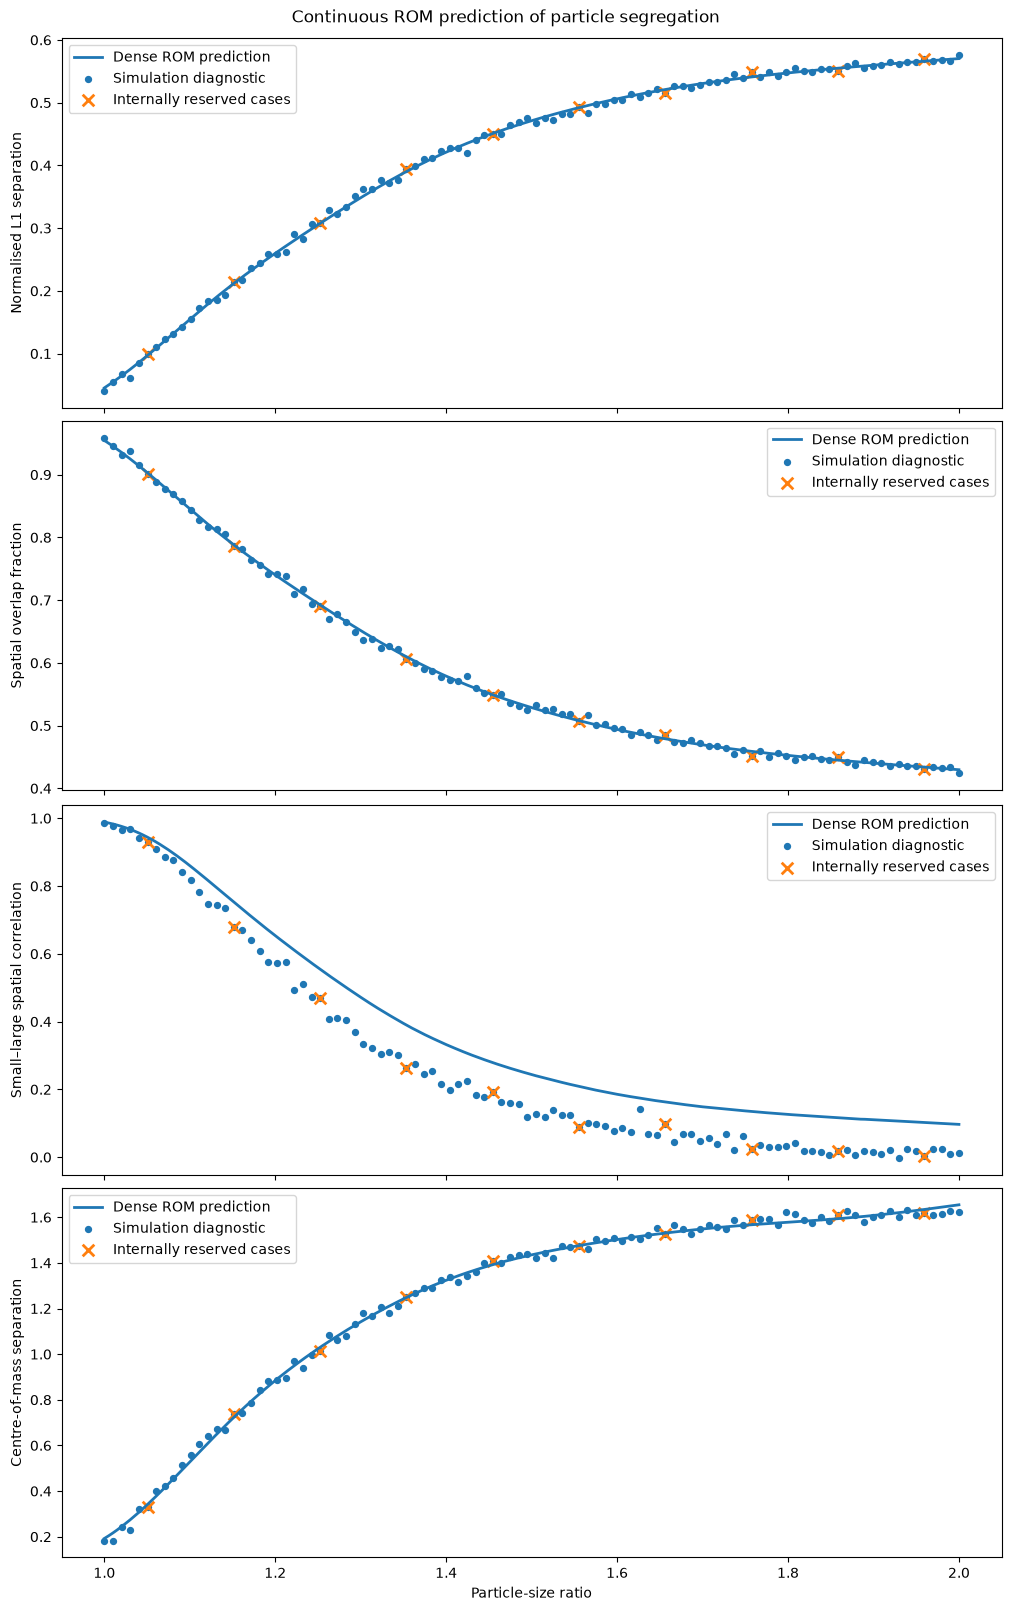

Saved segregation-sweep figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_consistent_rom_segregation_sweep.pdf


In [6]:
figure, axes = plt.subplots(
    4,
    1,
    figsize=(10, 16),
    sharex=True,
    constrained_layout=True,
)


plot_definitions = [
    (
        "normalised_l1_separation",
        "Normalised L1 separation",
    ),
    (
        "overlap_fraction",
        "Spatial overlap fraction",
    ),
    (
        "small_large_spatial_correlation",
        "Small–large spatial correlation",
    ),
    (
        "centre_of_mass_separation",
        "Centre-of-mass separation",
    ),
]


for axis, (
    metric_name,
    axis_label,
) in zip(
    axes,
    plot_definitions,
):
    axis.plot(
        dense_rom_segregation_metrics[
            "size_ratio"
        ],
        dense_rom_segregation_metrics[
            metric_name
        ],
        linewidth=2,
        label="Dense ROM prediction",
    )

    axis.scatter(
        exact_segregation_metrics[
            "size_ratio"
        ],
        exact_segregation_metrics[
            metric_name
        ],
        s=18,
        label="Simulation diagnostic",
    )

    axis.scatter(
        reserved_exact_segregation_metrics[
            "size_ratio"
        ],
        reserved_exact_segregation_metrics[
            metric_name
        ],
        marker="x",
        s=70,
        linewidths=2,
        label="Internally reserved cases",
    )

    axis.set_ylabel(
        axis_label
    )

    axis.legend()


axes[-1].set_xlabel(
    "Particle-size ratio"
)

figure.suptitle(
    "Continuous ROM prediction of particle segregation"
)

segregation_comparison_figure_path = (
    FIGURE_DIR
    / "cg_phi_consistent_rom_segregation_sweep.pdf"
)

figure.savefig(
    segregation_comparison_figure_path,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved segregation-sweep figure:"
)

print(
    segregation_comparison_figure_path
)

Dense-sweep smoothness
----------------------


,field,parameter_step,mean_relative_adjacent_change,maximum_relative_adjacent_change,minimum_relative_adjacent_change
0,bulk,0.005,0.000374,0.000647,0.000254
1,small,0.005,0.002917,0.007142,0.000546
2,large,0.005,0.003002,0.007316,0.000660


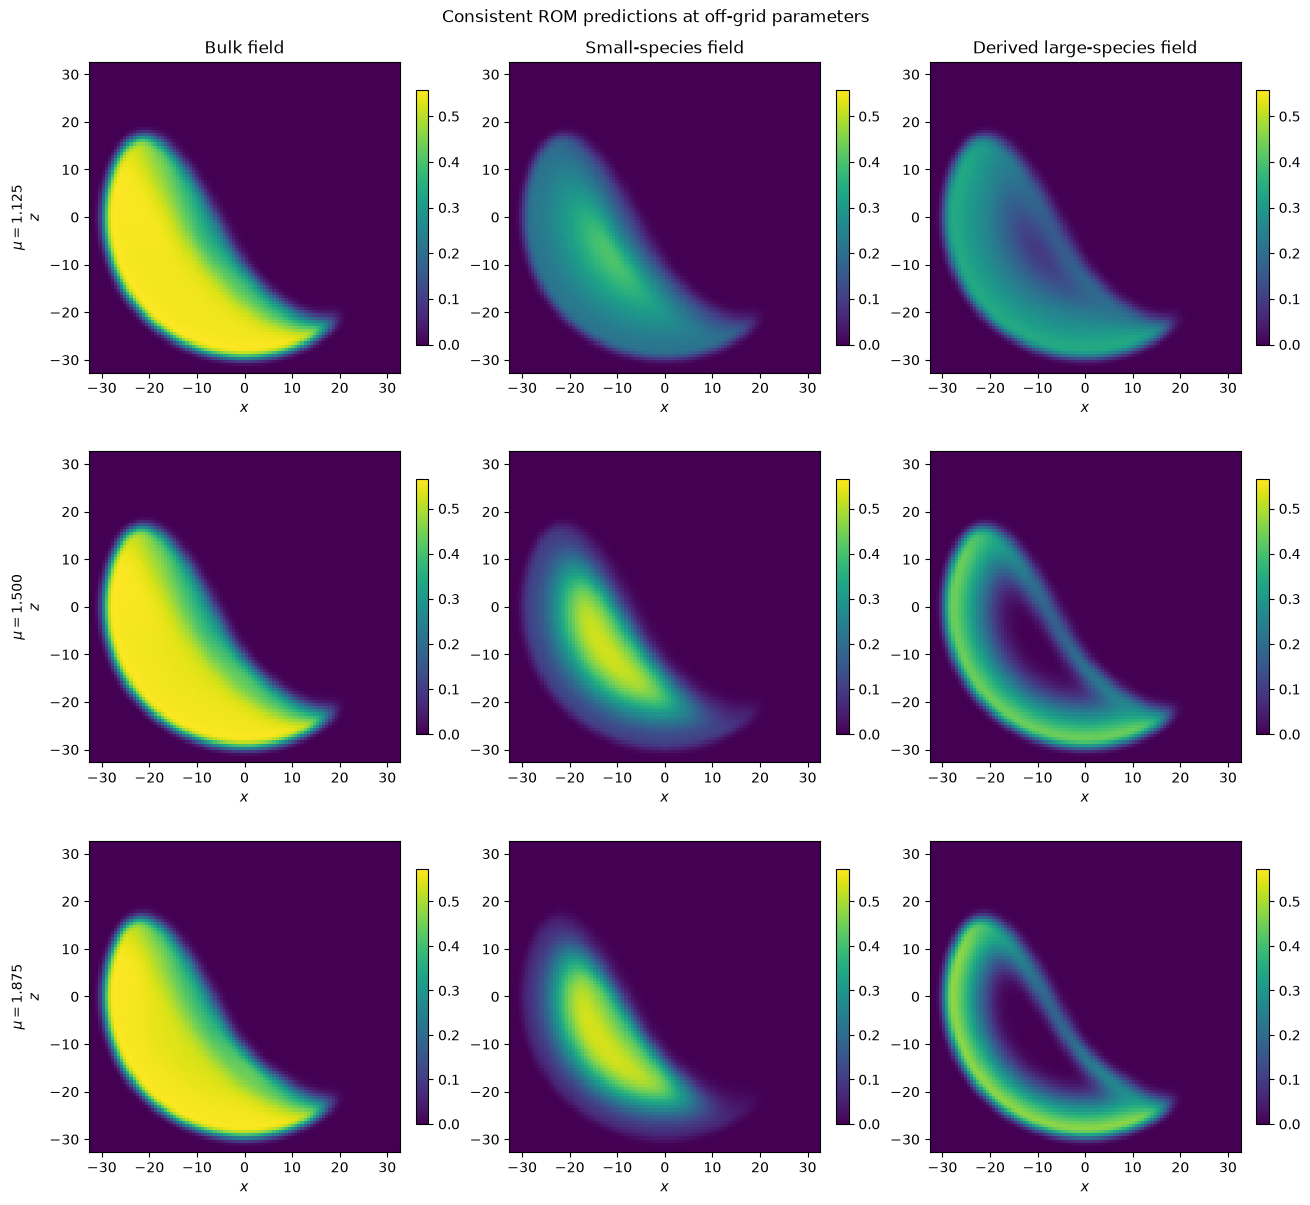

Saved smoothness summary:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_consistent_rom_sweep_smoothness.csv

Off-grid parameters:
[1.125 1.5   1.875]

Saved off-grid prediction figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_consistent_rom_off_grid_predictions.pdf


In [7]:
adjacent_step_records = []

parameter_step = float(
    np.diff(
        dense_parameters
    ).mean()
)

for field_name in [
    "bulk",
    "small",
    "large",
]:
    field_predictions = dense_predictions[
        field_name
    ]

    adjacent_differences = (
        field_predictions[
            :,
            1:,
        ]
        - field_predictions[
            :,
            :-1,
        ]
    )

    previous_norms = np.linalg.norm(
        field_predictions[
            :,
            :-1,
        ],
        axis=0,
    )

    relative_adjacent_changes = (
        np.linalg.norm(
            adjacent_differences,
            axis=0,
        )
        / previous_norms
    )

    adjacent_step_records.append(
        {
            "field": field_name,
            "parameter_step": (
                parameter_step
            ),
            "mean_relative_adjacent_change": float(
                relative_adjacent_changes.mean()
            ),
            "maximum_relative_adjacent_change": float(
                relative_adjacent_changes.max()
            ),
            "minimum_relative_adjacent_change": float(
                relative_adjacent_changes.min()
            ),
        }
    )


sweep_smoothness_summary = pd.DataFrame(
    adjacent_step_records
)

print("Dense-sweep smoothness")
print("----------------------")

display(
    sweep_smoothness_summary
)


smoothness_path = (
    TABLE_DIR
    / "cg_phi_consistent_rom_sweep_smoothness.csv"
)

sweep_smoothness_summary.to_csv(
    smoothness_path,
    index=False,
)


off_grid_parameters = np.array(
    [
        1.125,
        1.500,
        1.875,
    ]
)

# None of these values belongs to the original 100-point parameter grid.
original_parameter_values = (
    exact_segregation_metrics[
        "size_ratio"
    ].to_numpy()
)

for size_ratio in off_grid_parameters:
    assert not np.any(
        np.isclose(
            original_parameter_values,
            size_ratio,
            rtol=0.0,
            atol=1e-8,
        )
    )


off_grid_predictions = (
    predict_consistent_fields(
        consistent_rom_package,
        off_grid_parameters,
    )
)


def flattened_snapshot_to_field(
    snapshot: np.ndarray,
) -> np.ndarray:
    """Convert a flattened snapshot into a z-by-x field."""
    return snapshot.reshape(
        x_grid.size,
        z_grid.size,
    ).T


figure, axes = plt.subplots(
    off_grid_parameters.size,
    3,
    figsize=(13, 12),
    constrained_layout=True,
)


field_names = [
    "bulk",
    "small",
    "large",
]

field_titles = [
    "Bulk field",
    "Small-species field",
    "Derived large-species field",
]


for row_index, size_ratio in enumerate(
    off_grid_parameters
):
    row_fields = {
        field_name: (
            flattened_snapshot_to_field(
                off_grid_predictions[
                    field_name
                ][
                    :,
                    row_index,
                ]
            )
        )
        for field_name in field_names
    }

    shared_maximum = float(
        max(
            row_fields[
                field_name
            ].max()
            for field_name in field_names
        )
    )

    for column_index, field_name in enumerate(
        field_names
    ):
        image = axes[
            row_index,
            column_index,
        ].imshow(
            row_fields[
                field_name
            ],
            origin="lower",
            extent=(
                x_grid.min(),
                x_grid.max(),
                z_grid.min(),
                z_grid.max(),
            ),
            aspect="equal",
            interpolation="nearest",
            vmin=0.0,
            vmax=shared_maximum,
        )

        axes[
            row_index,
            column_index,
        ].set_xlabel(
            r"$x$"
        )

        if column_index == 0:
            axes[
                row_index,
                column_index,
            ].set_ylabel(
                rf"$\mu={size_ratio:.3f}$"
                "\n"
                r"$z$"
            )

        figure.colorbar(
            image,
            ax=axes[
                row_index,
                column_index,
            ],
            shrink=0.72,
        )


for column_index, title in enumerate(
    field_titles
):
    axes[
        0,
        column_index,
    ].set_title(
        title
    )


figure.suptitle(
    "Consistent ROM predictions at off-grid parameters"
)

off_grid_figure_path = (
    FIGURE_DIR
    / "cg_phi_consistent_rom_off_grid_predictions.pdf"
)

figure.savefig(
    off_grid_figure_path,
    bbox_inches="tight",
)

plt.show()


print("Saved smoothness summary:")
print(smoothness_path)

print("\nOff-grid parameters:")
print(off_grid_parameters)

print("\nSaved off-grid prediction figure:")
print(off_grid_figure_path)

## Conclusions

The final physically consistent reduced-order model was evaluated over a dense
sweep of 201 particle-size ratios between 1 and 2. No model fitting, POD-rank
selection or hyperparameter adjustment was performed in this notebook.

The packaged model directly predicts the bulk and small-species fields and
calculates the large-species field using

$$
\widehat{\phi}_{\mathrm{large}}
=
\widehat{\phi}_{\mathrm{bulk}}
-
\widehat{\phi}_{\mathrm{small}}.
$$

Consequently,

$$
\widehat{\phi}_{\mathrm{bulk}}
=
\widehat{\phi}_{\mathrm{small}}
+
\widehat{\phi}_{\mathrm{large}}
$$

was satisfied with zero numerical error throughout the complete parameter
sweep.

### Computational performance

A single parameter evaluation produced all three $100\times100$ fields in a
median time of approximately **0.854 ms**. A vectorised sweep of 201 parameter
values required approximately **25.31 ms**, equivalent to approximately
**0.126 ms per parameter** when evaluated as one batch.

The packaged model occupies approximately **0.445 MB**.

### Physical behaviour

The predicted integrated volumes remained nearly constant across the dense
parameter sweep:

- bulk volume ranged from approximately **565.531 to 565.555**;
- small-species volume ranged from approximately **282.753 to 282.778**;
- large-species volume ranged from approximately **282.766 to 282.801**.

Small negative reconstruction values were retained rather than removed through
clipping. The minimum predicted large-species value was approximately
$-2.51\times10^{-3}$.

The predictions changed smoothly between adjacent parameter values. For a
parameter increment of 0.005, the mean relative changes were approximately:

- **0.000374** for the bulk field;
- **0.002917** for the small-species field;
- **0.003002** for the large-species field.

The greater variation in the species fields is consistent with their stronger
dependence on size-driven segregation.

### Segregation predictions

Across the dense sweep, the ROM predicted:

- normalised L1 separation increasing from approximately **0.045 to 0.570**;
- spatial overlap decreasing from approximately **0.955 to 0.430**;
- centre-of-mass separation increasing from approximately **0.192 to 1.654**.

On the ten internally reserved simulations, the mean absolute errors were:

- **0.00329** for normalised L1 separation;
- **0.00328** for spatial overlap;
- **0.01157** for centre-of-mass separation.

These results show that the ROM reproduces the principal development of
particle segregation across the parameter interval.

The small–large spatial-correlation measure was less accurately reproduced,
with a mean absolute error of approximately **0.0877**. The ROM retained a
positive correlation bias at larger particle-size ratios, where the exact
correlation approached zero. This diagnostic is particularly sensitive to
small POD reconstruction values in low-density regions and should therefore be
interpreted more cautiously than the L1, overlap and centre-of-mass measures.

Finally, the packaged ROM generated complete fields at particle-size ratios
1.125, 1.500 and 1.875, none of which belongs to the original 100-point
simulation grid. These examples demonstrate continuous interpolation within
the fitted parameter interval rather than extrapolation beyond the available
data.